# How Kronos sorts and clusters events: a worked example

A TimePix camera does not record images. It records **events**: every time a pixel fires it
writes one row `(x, y, toa, tot)`: where, *time of arrival* (25 ns ticks) and *time over
threshold* (≈ deposited charge). One electron usually fires one to four neighboring pixels
within a tick, so the physics lives in **clusters** of events, about one per electron.

Two things make this hard on real data:

1. **The events arrive out of order**, split over many files.
2. **The data are far too big for memory** (TestSeq1_1k: ~10 billion events, 188 GB).

Kronos solves this in one streaming pass:

```
raw HDF5 files ──merge_sort──▶ toa-sorted parts ──cluster_parts──▶ one row per cluster
 (out of order)     (sort.py)     (bounded memory)    (cluster.py)     (Parquet tables)
```

This notebook runs **the real `kronos` functions** on a toy detector small enough to see every
event: a **10 × 10 pixel grid** and times **1 to 100 ticks**. Along the way we rebuild each
algorithm in a few lines of plain Python to trace what it does, and check that the
traced version agrees with the package.

**Contents**

1. A toy dataset with known electrons
2. How the events arrive: files, blocks and local shuffling
3. Sorting, part 1: counting sort inside memory (`time_order`)
4. Sorting, part 2: streaming many files with `merge_sort`
5. Clustering: the rule
6. Clustering: one pass with a "latest event" image and union-find (`label_events`)
7. From clusters to electrons (`summarize_clusters`)
8. Choosing `dt_max`
9. Clustering a stream of parts (`cluster_parts`)
10. Summary

In [1]:
import shutil
import tempfile
from pathlib import Path
from unittest.mock import patch

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import FancyArrowPatch, Rectangle

from kronos.cluster import (
    cluster_parts,
    label_events,
    neighbor_time_gaps,
    summarize_clusters,
)
from kronos.events import concat, read_chunks
from kronos.sort import bucket_sort, merge_sort, time_order

%matplotlib inline

In [2]:
# One small, consistent plot style for the whole notebook.
INK, INK_2, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED = (
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948")
SERIES = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED]   # fixed order
BLUES = ["#104281", "#2a78d6", "#86b6ef", "#cde2fb"]                 # dark -> light

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK_2,
    "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.prop_cycle": plt.cycler(color=SERIES), "legend.frameon": False,
})

SIZE = 10      # the toy detector is SIZE x SIZE pixels
T_END = 100    # electrons arrive at toa 1 ... T_END - 1


def pixel_axes(ax, title=None):
    # Square 10 x 10 detector axes with a line between every pixel.
    ax.set(xlim=(-0.5, SIZE - 0.5), ylim=(-0.5, SIZE - 0.5), aspect="equal")
    ax.set_xticks(range(0, SIZE, 3)), ax.set_yticks(range(0, SIZE, 3))
    ax.set_xticks(np.arange(-0.5, SIZE), minor=True)
    ax.set_yticks(np.arange(-0.5, SIZE), minor=True)
    ax.grid(False)
    ax.grid(which="minor", color=GRID, linewidth=0.6)
    ax.tick_params(which="minor", length=0)
    if title:
        ax.set_title(title)

## 1. A toy dataset with known electrons

Each toy electron lands at a random time `t0` and pixel, and fires the pixel it hit plus 0–3
**edge-adjacent** neighbors (charge sharing), in roughly the proportions measured on real
data (36 % one pixel, 52 % two, …). Each event fires at `t0` or `t0 + 1`, like real data where
same-electron events arrive within 0–1 tick.

To keep the answer unambiguous, an electron is only kept if no earlier electron landed within
2 pixels *and* 4 ticks of it. So we know the true electron of every event and can check the
clustering exactly.

In [3]:
EDGE_NEIGHBORS = [(1, 0), (-1, 0), (0, 1), (0, -1)]


def make_events(n_electrons=55, seed=4):
    # Toy events sorted by toa, with the true electron of each event.
    rng = np.random.default_rng(seed)
    electrons = []                                  # (t0, [pixels])
    while len(electrons) < n_electrons:
        t0 = int(rng.integers(1, T_END))
        cx, cy = (int(v) for v in rng.integers(0, SIZE, 2))
        n_pixels = 1 + rng.choice(4, p=[0.36, 0.52, 0.09, 0.03])
        pixels = [(cx, cy)]
        for k in rng.permutation(4):
            dx, dy = EDGE_NEIGHBORS[k]
            if len(pixels) < n_pixels and 0 <= cx + dx < SIZE and 0 <= cy + dy < SIZE:
                pixels.append((cx + dx, cy + dy))
        too_close = any(abs(t0 - t) <= 4 and abs(px - qx) <= 2 and abs(py - qy) <= 2
                        for t, others in electrons for qx, qy in others for px, py in pixels)
        if not too_close:
            electrons.append((t0, pixels))

    rows = [(px, py, t0 + int(rng.integers(0, 2)), int(rng.integers(4, 30)), e)
            for e, (t0, pixels) in enumerate(sorted(electrons)) for px, py in pixels]
    x, y, toa, tot, electron = np.array(rows).T
    order = np.argsort(toa, kind="stable")
    return {"x": x[order].astype(np.uint16), "y": y[order].astype(np.uint16),
            "toa": toa[order].astype(np.uint64), "tot": tot[order].astype(np.uint16),
            "electron": electron[order]}


truth = make_events()
n_events, n_electrons = len(truth["toa"]), truth["electron"].max() + 1
print(f"{n_events} events from {n_electrons} electrons, toa {truth['toa'].min()}–{truth['toa'].max()}")
pd.DataFrame(truth).head(8)

110 events from 55 electrons, toa 3–100


,x,y,toa,tot,electron
0,6,4,3,26,0
1,5,4,3,23,0
2,6,5,4,4,0
3,2,4,5,25,1
4,1,4,6,19,1
5,0,8,6,15,2
6,5,0,6,17,4
7,0,9,7,24,2


Below, on the left, is what an ordinary camera would give you: every hit summed over the whole
run. All timing information is gone and neighboring electrons blur together. On the right
are just the events in one 10-tick slice, colored by their **true** electron: within a
short time window the electrons separate cleanly. That is why clustering needs the time order.

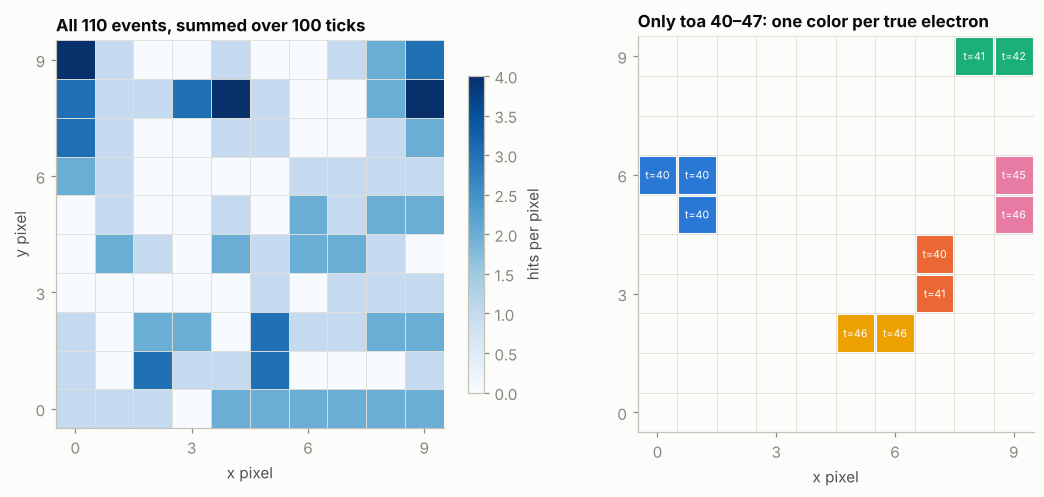

In [4]:
fig, (ax_image, ax_slice) = plt.subplots(1, 2, figsize=(10, 4.6))

image = np.zeros((SIZE, SIZE))
np.add.at(image, (truth["y"], truth["x"]), 1)
shown = ax_image.imshow(image, origin="lower", cmap="Blues", vmin=0)
pixel_axes(ax_image, f"All {n_events} events, summed over 100 ticks")
fig.colorbar(shown, ax=ax_image, shrink=0.8, label="hits per pixel")

t_from, t_to = 40, 48
in_slice = (truth["toa"] >= t_from) & (truth["toa"] < t_to)
for k, e in enumerate(np.unique(truth["electron"][in_slice])):
    mine = in_slice & (truth["electron"] == e)
    for px, py, t in zip(truth["x"][mine], truth["y"][mine], truth["toa"][mine]):
        ax_slice.add_patch(Rectangle((px - 0.5, py - 0.5), 1, 1, color=SERIES[k], ec=SURFACE, lw=2))
        ax_slice.text(px, py, f"t={t}", ha="center", va="center", fontsize=7, color="white")
pixel_axes(ax_slice, f"Only toa {t_from}–{t_to - 1}: one color per true electron")
ax_image.set(xlabel="x pixel", ylabel="y pixel"), ax_slice.set(xlabel="x pixel")
plt.tight_layout()
plt.show()

## 2. How the events arrive: files, blocks and local shuffling

The real Timepix4 writes 16 `proc` files. We measured how they divide the events
(see `claude/sort-and-cluster-design.md` in the project):

* **Time round-robin.** Time is cut into blocks of 2¹⁴ ticks; file *k* gets the blocks with
  `(toa >> 14) % 16 == k`.
* **Locally shuffled.** Inside a file, events are almost in order: 99.9 % are within ~250
  ticks of their place, the worst within ~16 000 ticks.

The toy copies this with **4 files**, **blocks of 8 ticks** (`(toa // 8) % 4`) and each event
displaced by up to **3 ticks**. Files are written in the same HDF5 layout as the real data
(one dataset per column), so `kronos` reads them exactly as it reads real files.

In [5]:
N_FILES, BLOCK, JITTER = 4, 8, 3
workdir = Path(tempfile.mkdtemp(prefix="kronos_toy_"))


def write_files(events, directory, jitter=JITTER, seed=1):
    # Split events into N_FILES HDF5 files by time block; jitter=None shuffles fully.
    rng = np.random.default_rng(seed)
    directory.mkdir(parents=True, exist_ok=True)
    owner = (events["toa"].astype(int) // BLOCK) % N_FILES
    paths = []
    for f in range(N_FILES):
        rows = np.flatnonzero(owner == f)
        if jitter is None:
            rows = rng.permutation(rows)
        else:   # sort by a noisy time: each event moves by less than jitter + 1 ticks
            noisy_toa = events["toa"][rows] + rng.uniform(0, jitter + 1, len(rows))
            rows = rows[np.argsort(noisy_toa)]
        path = directory / f"toy_proc{f}.h5"
        with h5py.File(path, "w") as h5:
            for name in ("x", "y", "toa", "tot"):
                h5[name] = events[name][rows]
        paths.append(path)
    return paths


files = write_files(truth, workdir / "raw")
raw = [concat(list(read_chunks(path))) for path in files]
[f"{path.name}: {len(r['toa'])} events" for path, r in zip(files, raw)]

['toy_proc0.h5: 35 events',
 'toy_proc1.h5: 26 events',
 'toy_proc2.h5: 21 events',
 'toy_proc3.h5: 28 events']

**Disorder.** How shuffled is a file? Walk through it keeping the running maximum of `toa`;
an event that is *below* the running maximum arrived late. The file's **disorder** is the
largest such drop:

```python
disorder = (np.maximum.accumulate(toa) - toa).max()
```

In the plots, each dot is an event in file order, the gray line is the running maximum and
the red arrow marks the worst late arrival. Note the gaps in time: each file only holds every
4th block.

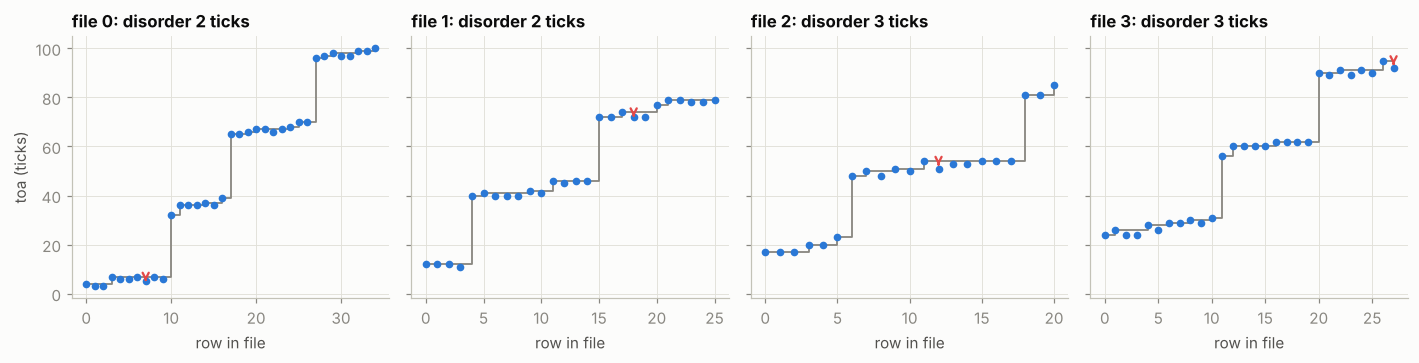

In [6]:
def disorder(toa):
    toa = np.asarray(toa, np.int64)
    return int((np.maximum.accumulate(toa) - toa).max())


fig, axes = plt.subplots(1, N_FILES, figsize=(13, 3.4), sharey=True)
for f, (ax, events) in enumerate(zip(axes, raw)):
    toa = events["toa"].astype(int)
    running_max = np.maximum.accumulate(toa)
    worst = int(np.argmax(running_max - toa))
    ax.step(range(len(toa)), running_max, where="post", color=MUTED, lw=1.2)
    ax.plot(toa, "o", ms=4, color=BLUE)
    ax.annotate("", xy=(worst, toa[worst]), xytext=(worst, running_max[worst]),
                arrowprops=dict(arrowstyle="->", color=RED, lw=1.5))
    ax.set_title(f"file {f}: disorder {disorder(toa)} ticks")
    ax.set_xlabel("row in file")
axes[0].set_ylabel("toa (ticks)")
plt.tight_layout()
plt.show()

If we simply read the files one after the other, time jumps around wildly. Sorting has to
put the whole stream into one global time order (the right panel). The next two sections
show how.

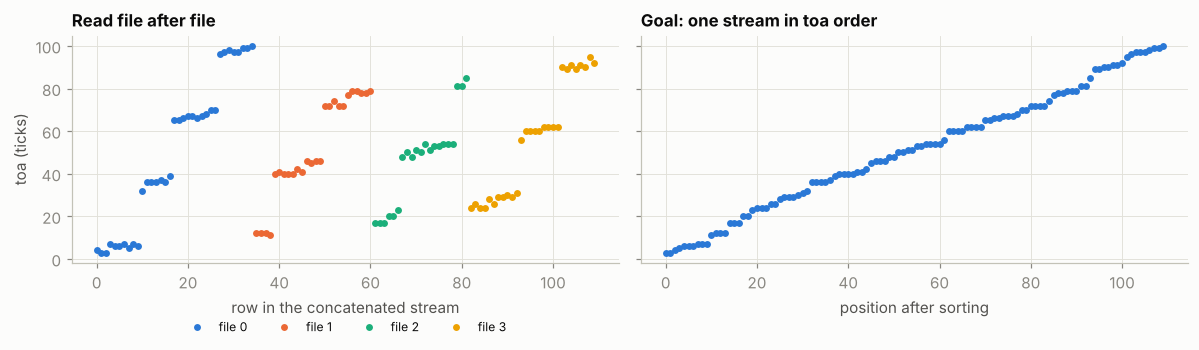

In [7]:
everything = concat(raw)                       # file 0, then file 1, ...
fig, (ax_raw, ax_sorted) = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
starts = np.cumsum([0] + [len(r["toa"]) for r in raw])
for f in range(N_FILES):
    rows = np.arange(starts[f], starts[f + 1])
    ax_raw.plot(rows, everything["toa"][rows], "o", ms=3.5, color=SERIES[f], label=f"file {f}")
ax_raw.set(title="Read file after file", xlabel="row in the concatenated stream", ylabel="toa (ticks)")
ax_raw.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.2), fontsize=8)
ax_sorted.plot(np.sort(everything["toa"]), "o", ms=3.5, color=BLUE)
ax_sorted.set(title="Goal: one stream in toa order", xlabel="position after sorting")
plt.tight_layout()
plt.show()

## 3. Sorting, part 1: counting sort inside memory (`time_order`)

Whatever is in memory gets sorted by `kronos.sort.time_order`. `toa` values are integers, and
within one part they span a small range, so instead of comparing values (argsort,
O(n log n)) we can **count** them (O(n + span), about 6× faster on real parts):

1. **Count** how many events have each `toa` value.
2. **Prefix sum.** The running total of counts gives the first output slot for each value.
3. **Place.** Walk the input once; put each event in the next free slot of its value.

Walking the input in order also makes it **stable**: events with equal `toa` keep their input
order. Here is the same algorithm in plain Python, returning the intermediate arrays so we
can draw them. (The package compiles this loop with numba.)

In [8]:
def counting_sort_order(toa):
    # The indices that sort toa, plus the counts and starts used to find them.
    t = np.asarray(toa, np.int64)
    first, span = t.min(), t.max() - t.min()
    counts = np.zeros(span + 1, dtype=int)
    for value in t:                                   # 1. count
        counts[value - first] += 1
    starts = np.cumsum(counts) - counts               # 2. first slot per value
    next_slot = starts.copy()
    order = np.empty(len(t), dtype=int)
    for i, value in enumerate(t):                     # 3. place, in input order
        order[next_slot[value - first]] = i
        next_slot[value - first] += 1
    return order, counts, starts


example = raw[0]["toa"][:10].astype(int)              # the first 10 events of file 0
order, counts, starts = counting_sort_order(example)
assert np.array_equal(order, time_order(example))     # same answer as the package
print("input toa :", example)
print("sorted toa:", example[order])

input toa : [4 3 3 7 6 6 7 5 7 6]
sorted toa: [3 3 4 5 6 6 6 7 7 7]


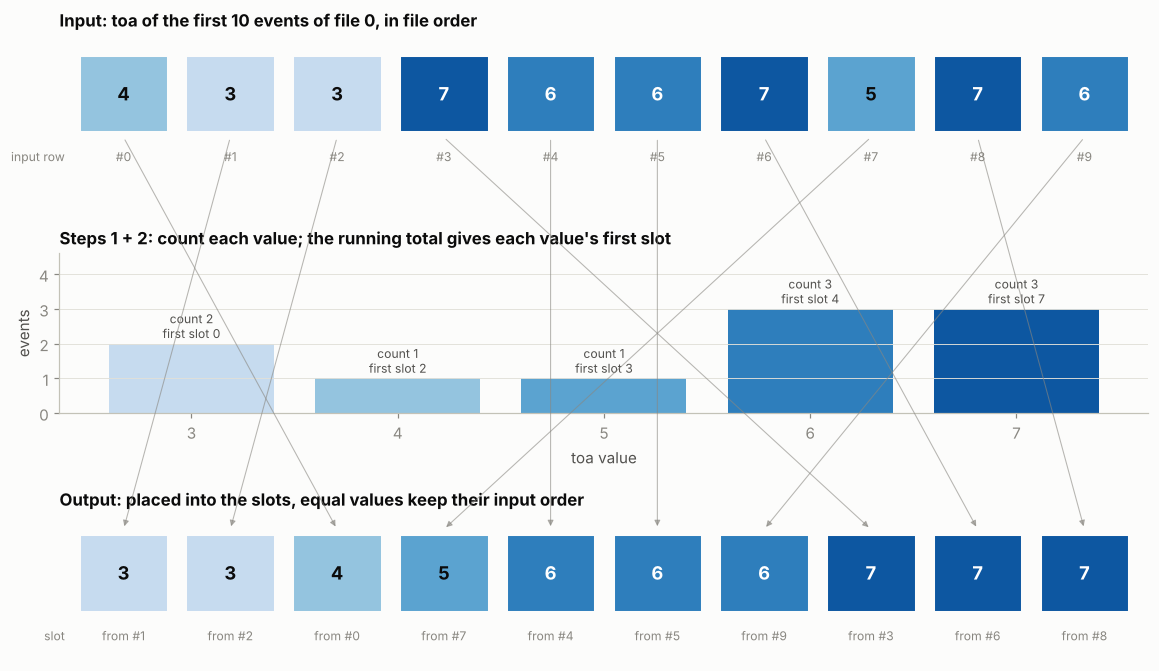

In [9]:
first = example.min()
values = np.arange(first, example.max() + 1)


def shade(value):
    return plt.cm.Blues(0.25 + 0.6 * (value - first) / max(1, np.ptp(values)))



fig = plt.figure(figsize=(11, 6.6))
ax_in, ax_count, ax_out = fig.add_axes([0.05, 0.72, 0.9, 0.2]), fig.add_axes(
    [0.05, 0.40, 0.9, 0.22]), fig.add_axes([0.05, 0.06, 0.9, 0.2])
for ax in (ax_in, ax_out):
    ax.set(xlim=(-0.6, len(example) - 0.4), ylim=(-0.9, 0.6))
    ax.axis("off")


def draw_boxes(ax, toa, labels, label_title):
    for k, (value, label) in enumerate(zip(toa, labels)):
        ax.add_patch(Rectangle((k - 0.42, -0.4), 0.84, 0.8, color=shade(value), ec=SURFACE, lw=2))
        ax.text(k, 0, value, ha="center", va="center", fontsize=12, weight="bold",
                color="white" if value - first > np.ptp(values) / 2 else INK)
        ax.text(k, -0.65, label, ha="center", va="center", fontsize=8, color=MUTED)
    ax.text(-0.55, -0.65, label_title, ha="right", va="center", fontsize=8, color=MUTED)


draw_boxes(ax_in, example, [f"#{i}" for i in range(len(example))], "input row")
ax_in.set_title("Input: toa of the first 10 events of file 0, in file order", loc="left")
draw_boxes(ax_out, example[order], [f"from #{i}" for i in order], "slot")
ax_out.set_title("Output: placed into the slots, equal values keep their input order", loc="left")

bars = ax_count.bar(values, counts, width=0.8, color=[shade(v) for v in values])
for v, c, s in zip(values, counts, starts):
    ax_count.text(v, c + 0.08, f"count {c}\nfirst slot {s}" if c else "count 0", ha="center",
                  va="bottom", fontsize=8, color=INK_2)
ax_count.set(xticks=values, ylim=(0, counts.max() + 1.6), xlabel="toa value", ylabel="events")
ax_count.set_title("Steps 1 + 2: count each value; the running total gives each value's first slot",
                   loc="left")
ax_count.grid(axis="x", visible=False)

# Arrows from each input box to its output slot (figure coordinates).
slot_of = np.empty(len(example), int)
slot_of[order] = np.arange(len(example))


def to_fig(ax, x, y):
    return fig.transFigure.inverted().transform(ax.transData.transform((x, y)))


for i, slot in enumerate(slot_of):
    start, end = to_fig(ax_in, i, -0.45), to_fig(ax_out, slot, 0.45)
    fig.patches.append(FancyArrowPatch(start, end, transform=fig.transFigure, arrowstyle="-|>",
                                       mutation_scale=8, color=MUTED, lw=0.7, alpha=0.6, zorder=0))
plt.show()

Counting sort needs one counter per possible value, so it only pays off when the span of
values is small compared with the number of events. That is true inside a part (2 M events
over a few ms of ticks), so `time_order` uses it there and falls back to `argsort` otherwise.
On the whole toy dataset at once it gives the stream we are aiming for:

In [10]:
reference = {name: everything[name][time_order(everything["toa"])] for name in everything}


def same_events(a, b):
    # True if a and b hold the same events (order of equal-toa events may differ).
    a_order = np.lexsort((a["x"], a["y"], a["toa"]))
    b_order = np.lexsort((b["x"], b["y"], b["toa"]))
    return all(np.array_equal(a[n][a_order], b[n][b_order]) for n in ("x", "y", "toa", "tot"))


assert np.all(np.diff(reference["toa"].astype(int)) >= 0)
print(f"sorted {len(reference['toa'])} events in memory; this is the answer merge_sort must match")

sorted 110 events in memory; this is the answer merge_sort must match


## 4. Sorting, part 2: streaming many files with `merge_sort`

On real data we cannot load everything and sort it. `merge_sort` reads all files **once, front to
back, in small chunks**, and gives back toa-sorted **parts** as soon as it can prove they are
final. The proof uses one number, `max_disorder`, an upper bound on any file's disorder:

> If the newest `toa` read so far from file *f* is `newest[f]`, every unread event of that file
> has `toa ≥ newest[f] − max_disorder`. So no unread event, in any file, is older than
>
> &nbsp;&nbsp;&nbsp;&nbsp;**`safe = min over files of newest[f] − max_disorder`**.
>
> Everything in memory older than `safe` can be sorted and handed on: nothing will ever be
> inserted before it.

The loop, in words:

1. Read the next chunk from the file that is **furthest behind** in time (smallest `newest`).
   This keeps the files in step and pushes `safe` forward as fast as possible.
2. Once the buffer holds enough events, split it at `safe`: older events are counting-sorted
   and **yielded as a part**; younger ones stay in the buffer.
3. If a chunk ever contains an event older than what was already yielded, the files are more
   shuffled than `max_disorder`: raise `ValueError`.

Toy settings: chunks of 6 rows, `part_rows = 12` (the buffer is split once it holds
`part_rows` + one chunk per file = 36 events), `max_disorder = 4` ticks (the files have
disorder ≤ 3). Real defaults: chunks of 200 k rows, parts of 2 M, `max_disorder = 65 536`.

To watch it work we run the **real** `merge_sort` and only *spy* on it: `read_chunks` is
wrapped so that every chunk read is written to a log, and every part it yields is logged too.

In [11]:
CHUNK_ROWS, PART_ROWS, MAX_DISORDER = 6, 12, 4
log = []   # ("read", file, first_row, chunk) or ("part", part), in the order they happen


def spying_read_chunks(path, columns, chunk_rows):
    for k, chunk in enumerate(read_chunks(path, columns, chunk_rows)):
        log.append(("read", files.index(path), k * chunk_rows, chunk))
        yield chunk


with patch("kronos.sort.read_chunks", spying_read_chunks):
    for part in merge_sort(files, MAX_DISORDER, CHUNK_ROWS, PART_ROWS):
        log.append(("part", part))

parts = [entry[1] for entry in log if entry[0] == "part"]
assert same_events(concat(parts), reference)
print(f"{sum(e[0] == 'read' for e in log)} chunk reads, {len(parts)} parts, "
      f"identical to the in-memory sort ✓")
pd.DataFrame({"events": [len(p["toa"]) for p in parts],
              "first toa": [p["toa"][0] for p in parts],
              "last toa": [p["toa"][-1] for p in parts]}).rename_axis("part")

20 chunk reads, 5 parts, identical to the in-memory sort ✓


,events,first toa,last toa
part,,,
0,20,3,23
1,31,24,48
2,19,50,62
3,32,65,95
4,8,96,100


Now replay the log. Each panel is the state right after one chunk read (ringed in orange)
and any part yielded in response. Each lane is a file and each dot an event at its `toa`:

* **hollow gray**: still on disk,
* **blue**: read and waiting in memory,
* **dark**: already sorted and yielded in a part (the shaded region),
* **▼ orange**: each file's `newest` toa; the **dashed orange line** is `safe`.

Watch how the reader always tops up the file whose ▼ is furthest left, how `safe` trails the
slowest file by `max_disorder`, and how memory only ever holds a narrow band of time.

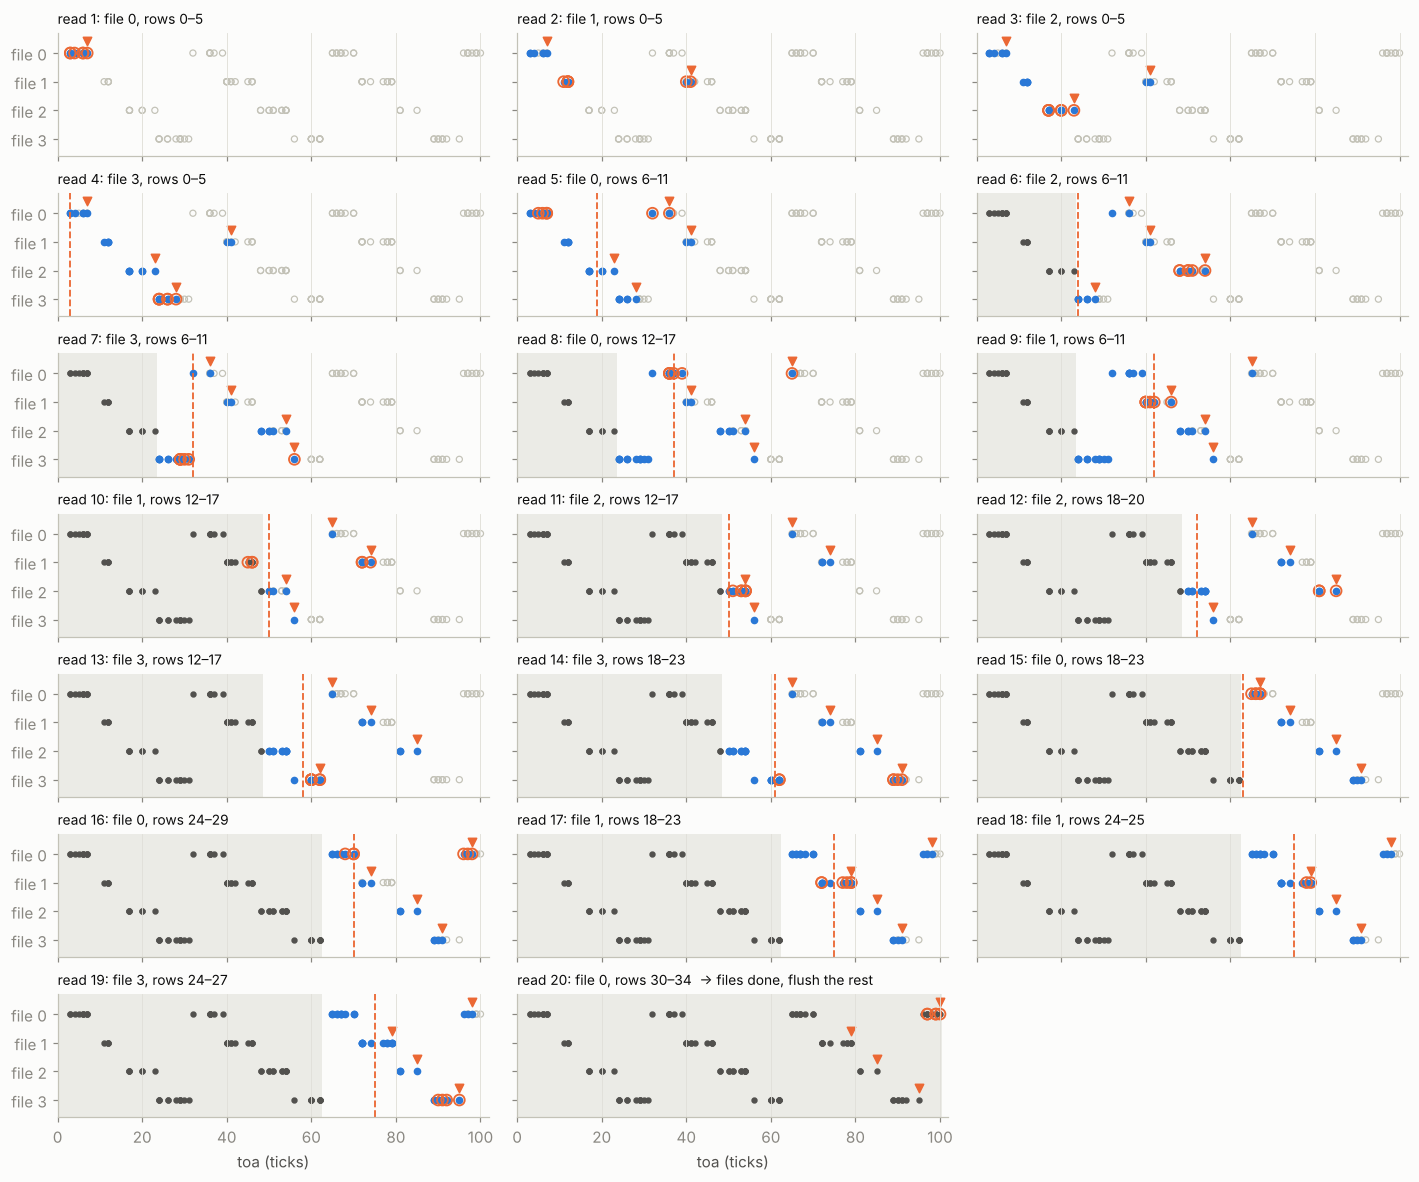

In [12]:
file_of = np.concatenate([np.full(len(r["toa"]), f) for f, r in enumerate(raw)])
row_of = np.concatenate([np.arange(len(r["toa"])) for r in raw])
toa_of = everything["toa"].astype(int)

state = np.zeros(len(toa_of), int)       # 0 on disk, 1 in memory, 2 yielded
newest = np.full(N_FILES, -1)
done_until, frames = -1, []
for entry in log:
    if entry[0] == "read":
        _, f, first_row, chunk = entry
        rows = (file_of == f) & (row_of >= first_row) & (row_of < first_row + len(chunk["toa"]))
        state[rows] = 1
        newest[f] = max(newest[f], int(chunk["toa"].max()))
        frames.append([state.copy(), newest.copy(), done_until, f, first_row, len(chunk["toa"])])
    else:   # a part was yielded right after the latest read: show it in that frame
        done_until = int(entry[1]["toa"].max())
        state[(state == 1) & (toa_of <= done_until)] = 2
        frames[-1][0], frames[-1][2] = state.copy(), done_until

n_cols = 3
n_rows = -(-len(frames) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 1.55 * n_rows), sharex=True, sharey=True)
for k, (ax, (st, nw, done, f, first_row, n)) in enumerate(zip(axes.flat, frames)):
    lane = N_FILES - 1 - file_of
    if done >= 0:
        ax.axvspan(0, done + 0.5, color=GRID, alpha=0.6, lw=0)
    ax.scatter(toa_of[st == 0], lane[st == 0], s=16, facecolor="none", edgecolor="#c3c2b7", lw=0.8)
    ax.scatter(toa_of[st == 1], lane[st == 1], s=16, color=BLUE)
    ax.scatter(toa_of[st == 2], lane[st == 2], s=10, color=INK_2)
    read_now = (file_of == f) & (row_of >= first_row) & (row_of < first_row + n)
    ax.scatter(toa_of[read_now], lane[read_now], s=50, facecolor="none", edgecolor=ORANGE, lw=1.2)
    reading = nw >= 0
    ax.scatter(nw[reading], N_FILES - 1 - np.flatnonzero(reading) + 0.42, marker="v", s=30, color=ORANGE)
    if reading.all() and k < len(frames) - 1:
        ax.axvline(nw.min() - MAX_DISORDER, color=ORANGE, ls="--", lw=1.2)
    last_read = k == len(frames) - 1
    title = f"read {k + 1}: file {f}, rows {first_row}–{first_row + n - 1}"
    ax.set_title(title + ("  → files done, flush the rest" if last_read else ""), fontsize=9,
                 weight="normal")
    ax.set(ylim=(-0.6, N_FILES - 0.3), xlim=(0, T_END + 2),
           yticks=range(N_FILES), yticklabels=[f"file {N_FILES - 1 - i}" for i in range(N_FILES)])
    ax.grid(axis="y", visible=False)
for ax in axes.flat[len(frames):]:
    ax.axis("off")
for ax in axes[-1]:
    ax.set_xlabel("toa (ticks)")
plt.tight_layout(h_pad=0.6)
plt.show()

**Too small a `max_disorder`.** The bound is a promise about the files. If we promise 1 tick
when the files are shuffled by 3, `merge_sort` notices an event older than a part it already
yielded and stops rather than produce a wrong order:

In [13]:
try:
    for _ in merge_sort(files, max_disorder=1, chunk_rows=CHUNK_ROWS, part_rows=PART_ROWS):
        pass
except ValueError as error:
    print("ValueError:", error)

ValueError: /tmp/kronos_toy_2yxudi5q/raw/toy_proc1.h5 jumps back more than 1 ticks


A larger `max_disorder` is always correct but holds more events in memory before they are
safe. On the real data, disorder is ≤ 16 k ticks and the default is 65 536, while the
round-robin files trail each other by up to a block (2¹⁴ ticks) anyway.

**Completely shuffled files: `bucket_sort`.** If the files were shuffled end to end (disorder ≈
the whole run) no useful bound exists. `bucket_sort` handles any order at the cost of temp
files and extra passes: it (1) counts events per coarse time bin to plan the parts, (2) appends
every event to the temp file of its part, then (3) loads, counting-sorts and yields one temp
file at a time.

In [14]:
shuffled_files = write_files(truth, workdir / "shuffled", jitter=None)
shuffled = [concat(list(read_chunks(path)))["toa"] for path in shuffled_files]
print("disorder per shuffled file:", [disorder(t) for t in shuffled])

try:
    list(merge_sort(shuffled_files, MAX_DISORDER, CHUNK_ROWS, PART_ROWS))
except ValueError as error:
    print("merge_sort:", error)

bucket_parts = list(bucket_sort(shuffled_files, workdir / "tmp"))
assert np.array_equal(concat(bucket_parts)["toa"], reference["toa"])
print(f"bucket_sort: {len(bucket_parts)} part(s), same toa order as the in-memory sort ✓")

disorder per shuffled file: [97, 68, 68, 71]
merge_sort: /tmp/kronos_toy_2yxudi5q/shuffled/toy_proc1.h5 jumps back more than 4 ticks
bucket_sort: 1 part(s), same toa order as the in-memory sort ✓


## 5. Clustering: the rule

Now the stream is in time order. Two events are **neighbors** when they are close in space
*and* in time:

$$|x_i - x_j| \le r,\qquad |y_i - y_j| \le r,\qquad |toa_i - toa_j| \le \Delta t_{max}$$

with `radius` $r = 1$ (the 3 × 3 square around a pixel) and `dt_max` $= 2$ ticks on the real
data. A **cluster** is a connected group: events linked by any chain of neighbors.

The obvious way, comparing every pair of events, costs O(n²): hopeless for 10⁹ events. (The
tests keep a KD-tree version as a slow reference.) Because the events are sorted, Kronos needs
just **one pass** over them.

## 6. Clustering: one pass with a "latest event" image and union-find

`label_events` walks the events in `toa` order and keeps two things:

* **`latest`**: an image the size of the detector holding, for every pixel, the index of the
  most recent event on it (−1 if none yet).
* **`parent`**: a *union-find* forest. Every event starts as its own cluster
  (`parent[i] = i`); `find(i)` follows parents to the cluster's **root**, and joining two
  clusters points one root at the other. We always keep the *earlier* event as the root, so
  each root is the first event of its cluster.

For each new event *i*:

1. Look at the `latest` event *j* on each pixel of the 3 × 3 square around *i*.
2. If `toa[i] − toa[j] ≤ dt_max`, join their clusters: `union(i, j)`.
3. Write *i* into `latest` at its own pixel.

**Why only the latest event per pixel?** Suppose pixel *p* fired at times *a* < *b* and the new
event comes at *t*. If the old one is close enough, *t − a ≤ dt_max*, then so is the newer one,
*t − b < t − a*. And *a* is already in *b*'s cluster: they share a pixel and *b − a < t − a ≤ dt_max*.
So linking to *b* alone gives the same clusters. This is what makes one pass enough.

Below is the same loop in plain Python (the package compiles it with numba), recording each
step so we can draw it.

In [15]:
DT_MAX, RADIUS = 2, 1


def label_events_traced(x, y, toa, dt_max, radius=1):
    # Plain-Python copy of kronos.cluster._label_sorted that records every step.
    x, y, t = (np.asarray(v, dtype=int) for v in (x, y, toa))
    parent = list(range(len(t)))
    latest = np.full((SIZE, SIZE), -1)        # latest event index on each pixel

    def find(i):
        while parent[i] != i:
            parent[i] = parent[parent[i]]     # path halving keeps the trees shallow
            i = parent[i]
        return i

    steps = []
    for i in range(len(t)):
        links = []
        for py in range(max(0, y[i] - radius), min(SIZE, y[i] + radius + 1)):
            for px in range(max(0, x[i] - radius), min(SIZE, x[i] + radius + 1)):
                j = latest[py, px]
                if j >= 0 and t[i] - t[j] <= dt_max:
                    a, b = find(i), find(j)
                    parent[max(a, b)] = min(a, b)      # the earlier event stays root
                    links.append(int(j))
        steps.append({"latest": latest.copy(), "links": links})
        latest[y[i], x[i]] = i

    labels, n_clusters = np.empty(len(t), dtype=int), 0
    for i in range(len(t)):                   # number roots in order of appearance
        root = find(i)
        if root == i:
            labels[i], n_clusters = n_clusters, n_clusters + 1
        else:
            labels[i] = labels[root]
    return labels, steps


x, y, toa = (reference[name].astype(int) for name in ("x", "y", "toa"))
traced_labels, steps = label_events_traced(x, y, toa, DT_MAX, RADIUS)
labels = label_events(x, y, toa, DT_MAX, RADIUS)
assert np.array_equal(traced_labels, labels)
print(f"{len(toa)} events → {labels.max() + 1} clusters; traced copy agrees with label_events ✓")

110 events → 55 clusters; traced copy agrees with label_events ✓


Here are eight consecutive steps. Each panel shows the `latest` image *just before* event *i*
is added, colored by how long ago that pixel last fired:

* **dark → light blue**: fired 0, 1 or 2 ticks ago (within `dt_max`, can link),
* **gray**: fired longer ago (too old, ignored), **blank**: never fired,
* **orange square**: the new event, with its 3 × 3 search square dashed,
* **orange lines**: the links it makes. No link means it starts a new cluster.

The small numbers are event indices (`#j` is the latest event on that pixel).

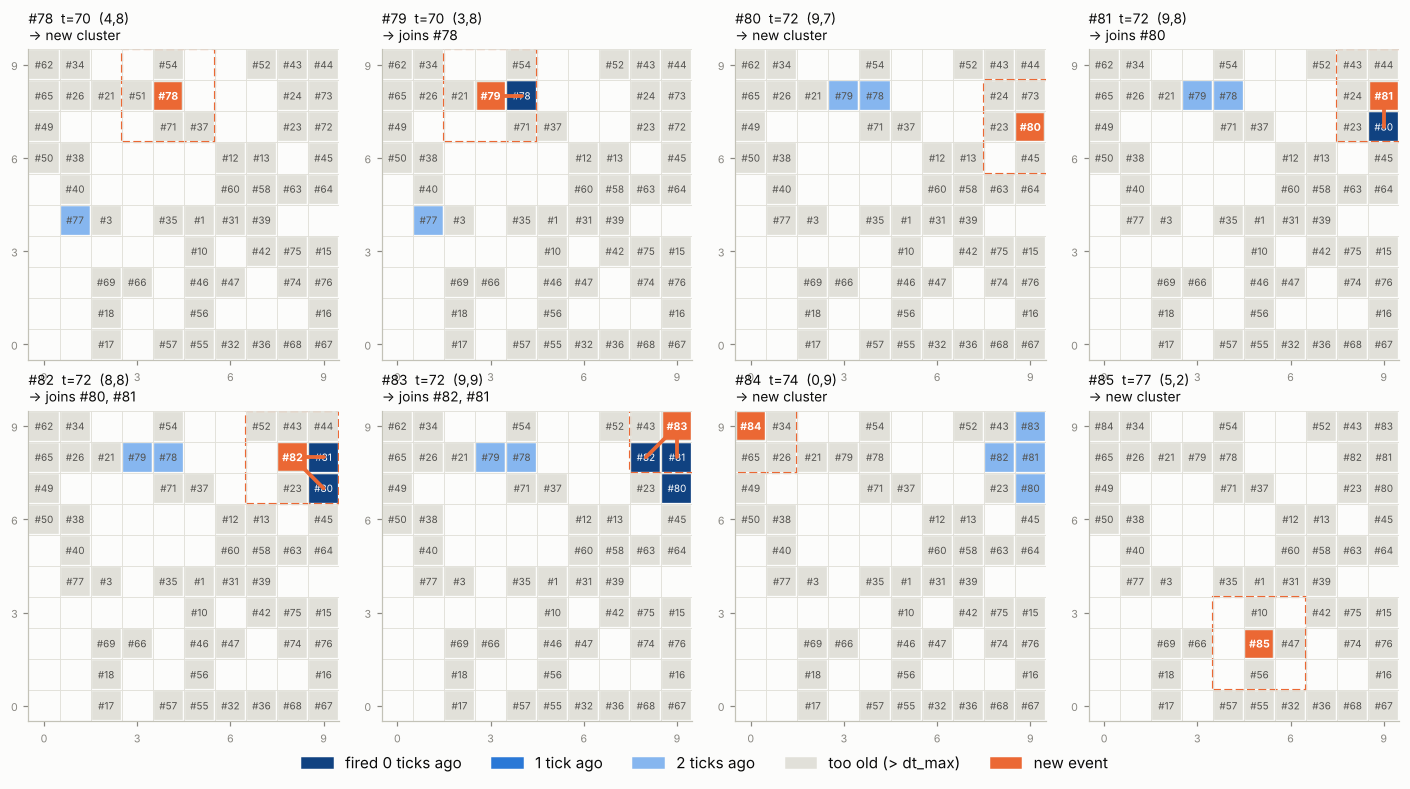

In [16]:
AGE_COLORS = BLUES[:3]          # age 0, 1, 2 ticks
TOO_OLD = GRID


def draw_step(ax, i):
    step = steps[i]
    for py in range(SIZE):
        for px in range(SIZE):
            j = step["latest"][py, px]
            if j < 0:
                continue
            age = toa[i] - toa[j]
            color = AGE_COLORS[age] if age <= DT_MAX else TOO_OLD
            ax.add_patch(Rectangle((px - 0.5, py - 0.5), 1, 1, color=color, ec=SURFACE, lw=1.5))
            ax.text(px, py, f"#{j}", ha="center", va="center", fontsize=6.5,
                    color="white" if age <= 1 else INK_2)
    ax.add_patch(Rectangle((x[i] - 1.5, y[i] - 1.5), 3, 3, fill=False, ec=ORANGE, lw=1.4, ls="--"))
    for j in step["links"]:
        ax.plot([x[i], x[j]], [y[i], y[j]], color=ORANGE, lw=2.5, solid_capstyle="round", zorder=4)
    ax.add_patch(Rectangle((x[i] - 0.42, y[i] - 0.42), 0.84, 0.84, color=ORANGE, zorder=5))
    ax.text(x[i], y[i], f"#{i}", ha="center", va="center", fontsize=7, color="white",
            weight="bold", zorder=6)
    joined = ", ".join(f"#{j}" for j in step["links"])
    verdict = f"joins {joined}" if joined else "new cluster"
    pixel_axes(ax)
    ax.set_title(f"#{i}  t={toa[i]}  ({x[i]},{y[i]})\n→ {verdict}", fontsize=9, weight="normal")
    ax.tick_params(labelsize=7)


# Start two events before the first 4-event electron, so we see joins and new clusters.
first_big = np.flatnonzero(np.bincount(labels)[labels] == 4)[0]
fig, axes = plt.subplots(2, 4, figsize=(13, 7))
for ax, i in zip(axes.flat, range(first_big - 2, first_big + 6)):
    draw_step(ax, i)
handles = [Rectangle((0, 0), 1, 1, color=c) for c in (*AGE_COLORS, TOO_OLD, ORANGE)]
fig.legend(handles, ["fired 0 ticks ago", "1 tick ago", "2 ticks ago", "too old (> dt_max)",
                     "new event"], ncol=5, loc="lower center", bbox_to_anchor=(0.5, -0.01))
plt.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

**The data as a point cloud.** Another way to see it: every event is a point in
(x, y, toa) space-time, and the links found above are short line segments. Clusters are tight
clumps strung along the time axis; the one-pass sweep moves left to right through this picture.

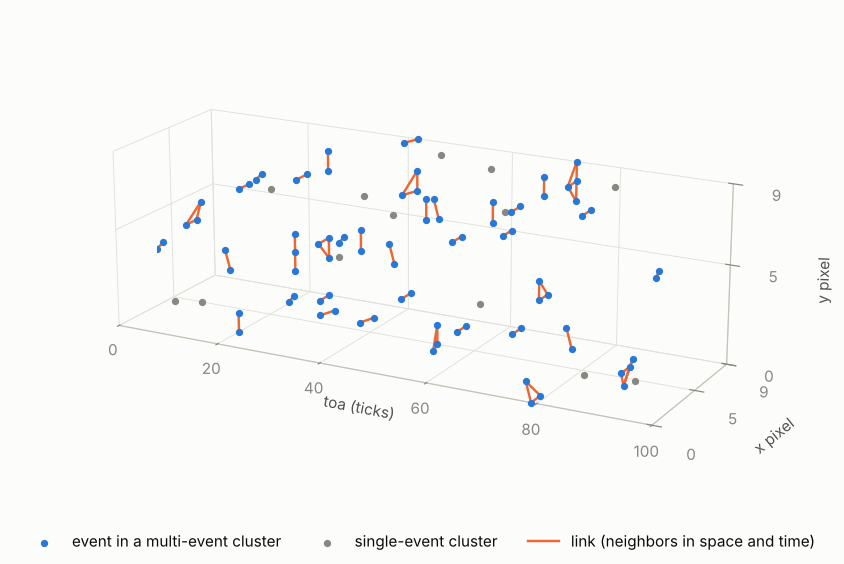

In [17]:
fig = plt.figure(figsize=(12, 5))
ax = fig.add_axes([0, 0.08, 1, 0.92], projection="3d")
for i, step in enumerate(steps):
    for j in step["links"]:
        ax.plot([toa[j], toa[i]], [x[j], x[i]], [y[j], y[i]], color=ORANGE, lw=1.6)
singles = np.bincount(labels)[labels] == 1
ax.scatter(toa[~singles], x[~singles], y[~singles], s=14, color=BLUE, depthshade=False,
           label="event in a multi-event cluster")
ax.scatter(toa[singles], x[singles], y[singles], s=14, color=MUTED, depthshade=False,
           label="single-event cluster")
ax.plot([], [], color=ORANGE, lw=1.6, label="link (neighbors in space and time)")
ax.set(xlabel="toa (ticks)", ylabel="x pixel", zlabel="y pixel", xlim=(0, T_END),
       ylim=(0, SIZE - 1), zlim=(0, SIZE - 1), yticks=[0, 5, 9], zticks=[0, 5, 9])
ax.set_box_aspect((3.2, 1, 1), zoom=1.25)
ax.view_init(elev=18, azim=-62)
for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
    axis.set_pane_color(SURFACE)
    axis._axinfo["grid"]["color"] = GRID
fig.legend(ncol=3, loc="lower center")
plt.show()

## 7. From clusters to electrons (`summarize_clusters`)

Labels are numbered 0, 1, 2, … in order of each cluster's first event. `summarize_clusters`
turns them into one row per cluster: first `toa`, `duration` (last − first toa), the
**ToT-weighted centroid** `x, y` (sub-pixel position of the electron), summed `tot` (≈ its
energy) and `n_events`.

First the check we can only do on a toy: is every cluster exactly one true electron?

In [18]:
# Look up the true electron of every sorted event (the files did not store it).
electron_of = pd.DataFrame(reference).merge(pd.DataFrame(truth), how="left")["electron"].to_numpy()
pairs = pd.DataFrame({"cluster": labels, "electron": electron_of})
one_to_one = (pairs.groupby("cluster").electron.nunique().eq(1).all()
              and pairs.groupby("electron").cluster.nunique().eq(1).all())
print(f"{labels.max() + 1} clusters, {n_electrons} electrons, one cluster per electron: {one_to_one}")

clusters = summarize_clusters(reference, labels)
clusters.head(8).round(2)

55 clusters, 55 electrons, one cluster per electron: True


,toa,duration,x,y,tot,n_events
0,3,1,5.57,4.08,53.0,3
1,5,1,1.57,4.00,44.0,2
2,6,1,0.00,8.47,43.0,3
3,6,0,5.00,0.00,17.0,1
4,7,0,2.00,1.00,27.0,1
5,11,1,5.00,2.48,40.0,2
6,12,0,6.59,6.00,27.0,2
7,17,0,9.00,2.18,22.0,3


Here is the whole run in ten 10-tick windows. Each colored group is one cluster (colors restart
in every window), the **+** is its ToT-weighted centroid and the number is its label. A smaller
inner square means the same pixel fired twice in that window, for two different electrons.
A cluster that straddles two windows shows its events in each, with the same centroid.

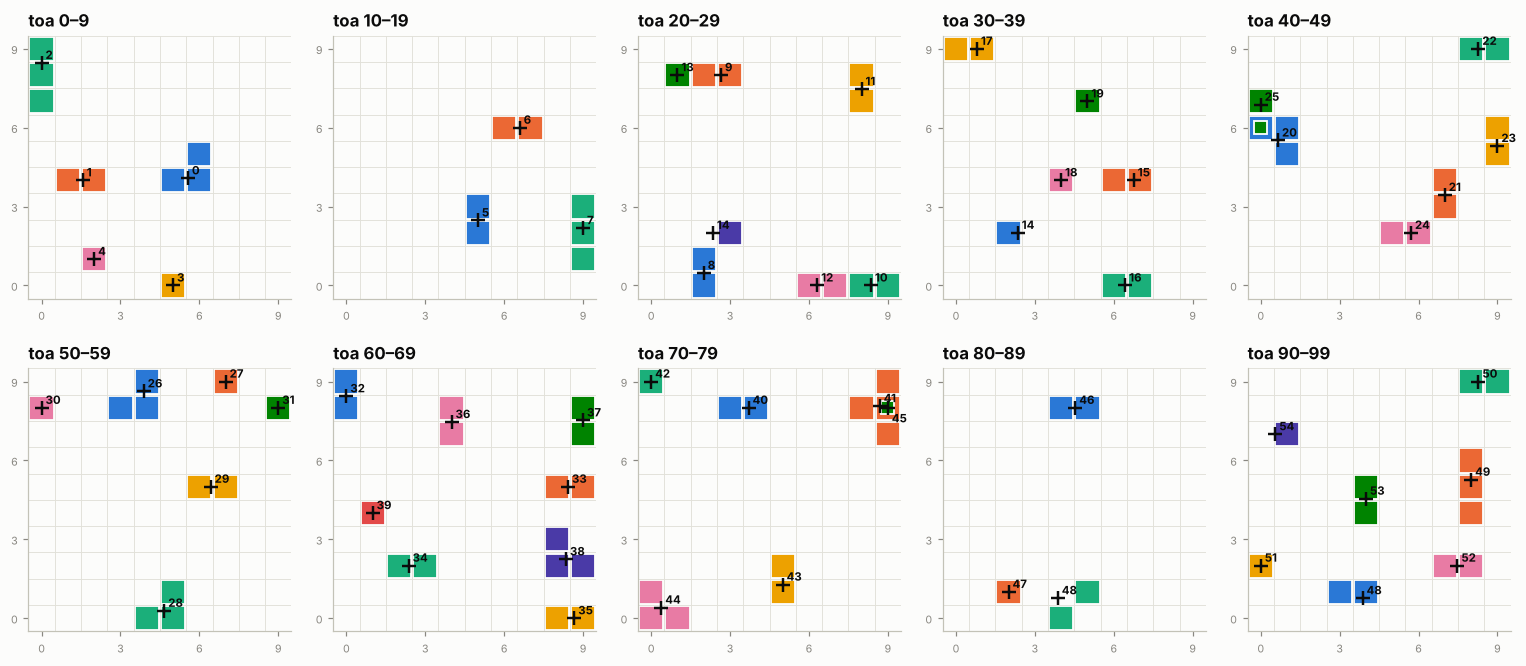

In [19]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6.2))
for ax, start in zip(axes.flat, range(0, T_END, 10)):
    in_window = (toa >= start) & (toa < start + 10)
    drawn, text_at = set(), []
    for k, label in enumerate(np.unique(labels[in_window])):
        color = SERIES[k % len(SERIES)]
        for i in np.flatnonzero(in_window & (labels == label)):
            size = 0.5 if (x[i], y[i]) in drawn else 0.92
            drawn.add((x[i], y[i]))
            ax.add_patch(Rectangle((x[i] - size / 2, y[i] - size / 2), size, size, color=color,
                                   ec=SURFACE, lw=1.2))
        row = clusters.loc[label]
        ax.plot(row.x, row.y, "+", color=INK, ms=9, mew=1.6)
        crowded = any(abs(row.x - tx) < 0.8 and abs(row.y - ty) < 0.8 for tx, ty in text_at)
        dy = -0.55 if crowded else 0.15                     # avoid stacking two labels
        ax.text(row.x + 0.15, row.y + dy, label, fontsize=7.5, color=INK, weight="bold")
        text_at.append((row.x, row.y))
    pixel_axes(ax, f"toa {start}–{start + 9}")
    ax.tick_params(labelsize=7)
plt.tight_layout()
plt.show()

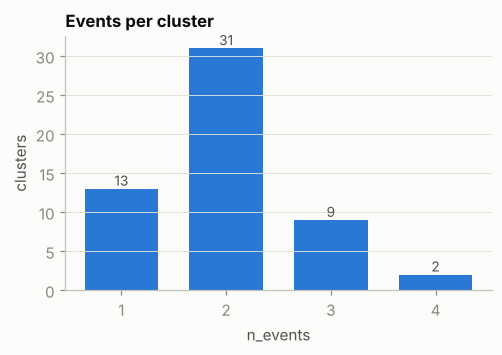

In [20]:
sizes = clusters.n_events.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(sizes.index, sizes.values, width=0.7, color=BLUE)
for n, count in sizes.items():
    ax.text(n, count + 0.4, count, ha="center", fontsize=9, color=INK_2)
ax.set(title="Events per cluster", xlabel="n_events", ylabel="clusters", xticks=sizes.index)
ax.grid(axis="x", visible=False)
plt.show()

On real data this split is 36 / 52 / 8 / 3 %, and the summed-ToT spectrum shows the
single-electron peak at ≈ 24 (the toy's ToT values are random, so we skip that plot here).

## 8. Choosing `dt_max`

`dt_max` decides everything: too small and one electron's events are split into several
clusters; too large and different electrons that happen to land close together are merged.

`neighbor_time_gaps` gives, for every event, the ticks since the **latest earlier event on a
neighboring pixel**. Same-electron events make a sharp peak at 0–1 ticks; unrelated events
make a flat floor of chance coincidences. Choose `dt_max` where the peak meets the floor.
On the right we simply re-cluster for every `dt_max` and count.

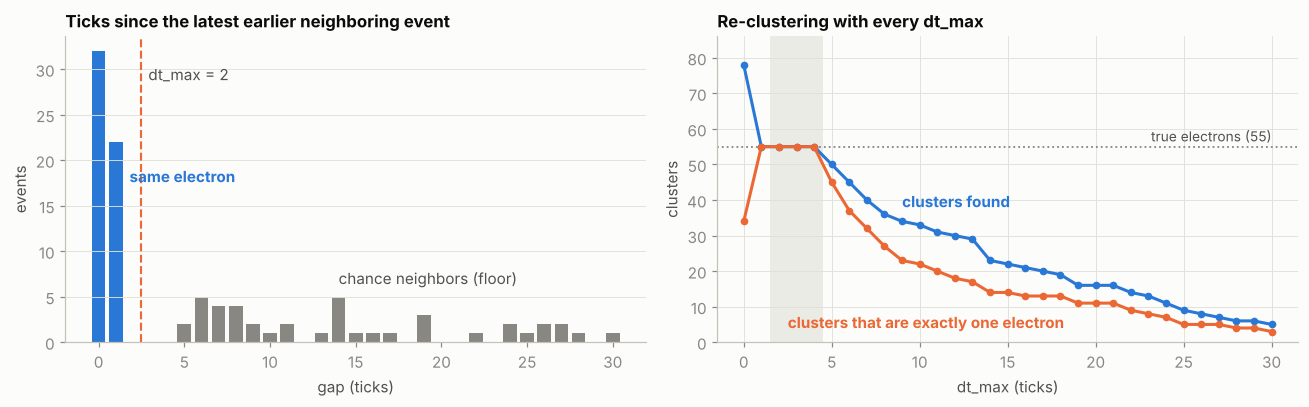

In [21]:
gaps = neighbor_time_gaps(x, y, toa, RADIUS)
dt_values = np.arange(0, 31)
n_found, n_exact = [], []
for dt in dt_values:
    found = label_events(x, y, toa, dt, RADIUS)
    pairs = pd.DataFrame({"cluster": found, "electron": electron_of})
    pure = pairs.groupby("cluster").electron.agg(["nunique", "first", "size"])
    true_size = np.bincount(electron_of)
    n_found.append(len(pure))
    n_exact.append(int(((pure["nunique"] == 1) & (pure["size"] == true_size[pure["first"]])).sum()))

fig, (ax_gap, ax_dt) = plt.subplots(1, 2, figsize=(12, 3.8))
counts = np.bincount(gaps[gaps >= 0], minlength=31)[:31]
ax_gap.bar(dt_values, counts, width=0.8, color=[BLUE if g <= DT_MAX else MUTED for g in dt_values])
ax_gap.axvline(DT_MAX + 0.5, color=ORANGE, ls="--", lw=1.4)
ax_gap.text(DT_MAX + 0.9, counts.max() * 0.9, f"dt_max = {DT_MAX}", color=INK_2)
ax_gap.text(1.8, counts.max() * 0.55, "same electron", color=BLUE, weight="bold")
ax_gap.text(14, counts.max() * 0.2, "chance neighbors (floor)", color=INK_2)
ax_gap.set(title="Ticks since the latest earlier neighboring event", xlabel="gap (ticks)",
           ylabel="events")
ax_gap.grid(axis="x", visible=False)

ax_dt.axhline(n_electrons, color=MUTED, ls=":", lw=1.2)
ax_dt.text(30, n_electrons + 1.5, f"true electrons ({n_electrons})", ha="right", color=INK_2, fontsize=9)
ax_dt.plot(dt_values, n_found, "-o", ms=4, lw=2, color=BLUE)
ax_dt.plot(dt_values, n_exact, "-o", ms=4, lw=2, color=ORANGE)
ax_dt.text(9, n_found[9] + 4, "clusters found", color=BLUE, weight="bold")
ax_dt.text(2.5, 4, "clusters that are exactly one electron", color=ORANGE, weight="bold")
ax_dt.axvspan(1.5, 4.5, color=GRID, alpha=0.6, lw=0)
ax_dt.set(title="Re-clustering with every dt_max", xlabel="dt_max (ticks)", ylabel="clusters",
          ylim=(0, max(n_found) + 8))
plt.tight_layout()
plt.show()

* `dt_max = 0` splits electrons whose events straddle two ticks (78 clusters).
* `dt_max = 2 … 4` (shaded) recovers every electron exactly. In the toy the floor starts at 5
  because we generated electrons at least 5 ticks apart when close in space.
* Beyond that, neighbors that have nothing to do with each other get merged.

On real data the floor starts at 2 ticks (chance rate ~740 events per tick per 5 M events),
hence `dt_max = 2`.

## 9. Clustering a stream of parts (`cluster_parts`)

`merge_sort` hands over one part at a time, and `cluster_parts` clusters each part as it
arrives. The only subtlety is the **edge** between parts: an electron that fires at the very end
of one part may have more events at the start of the next.

So after labeling a part, any cluster with an event in the last `dt_max` ticks of the part is
**still open**: it is not written out but **carried** into the next part, where it is labeled
again together with the new events. Every other cluster is final and written to that part's
table (`clusters-00000.parquet`, …).

The plot shows the toy run as `merge_sort` parted it (alternating colors), the window of the last
`dt_max` ticks at each part's end (shaded), and the events carried over (orange rings).

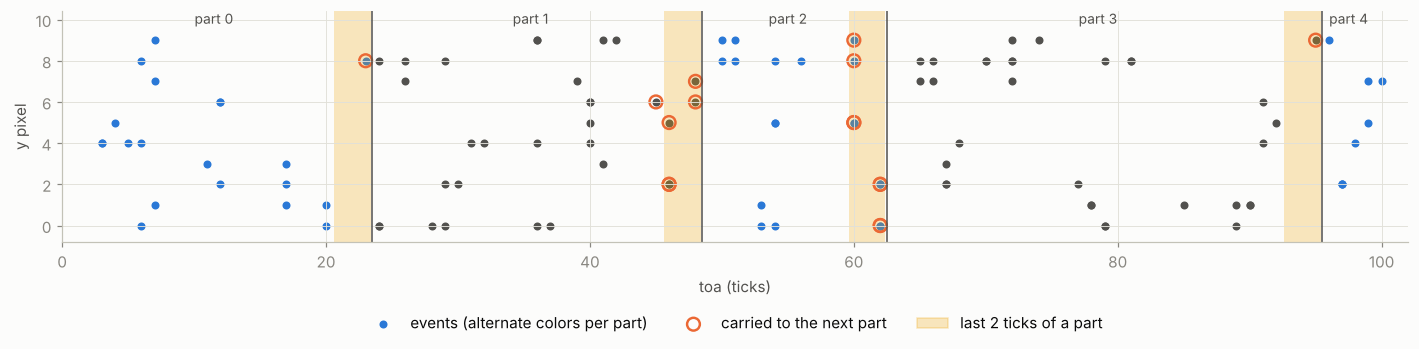

16 of 110 events were carried across a part boundary


In [22]:
part_last = np.array([int(p["toa"][-1]) for p in parts])
part_of = np.searchsorted(part_last, toa)                 # part index of each sorted event
carried = np.zeros(len(toa), bool)
for k, last in enumerate(part_last[:-1]):
    open_clusters = np.unique(labels[(part_of <= k) & (toa >= last - DT_MAX)])
    carried |= (part_of <= k) & np.isin(labels, open_clusters)

fig, ax = plt.subplots(figsize=(13, 3.4))
for k, last in enumerate(part_last):
    mine = part_of == k
    ax.scatter(toa[mine], y[mine], s=18, color=BLUE if k % 2 == 0 else INK_2,
               label="events (alternate colors per part)" if k == 0 else None)
    if k < len(part_last) - 1:
        ax.axvspan(last - DT_MAX - 0.4, last + 0.4, color=YELLOW, alpha=0.25, lw=0)
        ax.axvline(last + 0.5, color=INK_2, lw=1)
    ax.text((part_last[k - 1] + last) / 2 if k else last / 2, SIZE - 0.2, f"part {k}",
            ha="center", color=INK_2, fontsize=9)
ax.scatter(toa[carried], y[carried], s=70, facecolor="none", edgecolor=ORANGE, lw=1.6,
           label="carried to the next part")
ax.set(xlabel="toa (ticks)", ylabel="y pixel", ylim=(-0.8, SIZE + 0.4), xlim=(0, T_END + 2))
ax.axvspan(0, 0, color=YELLOW, alpha=0.25, label=f"last {DT_MAX} ticks of a part")
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.25))
plt.tight_layout()
plt.show()
print(f"{carried.sum()} of {len(toa)} events were carried across a part boundary")

Finally the real thing, end to end on the toy files: `merge_sort` feeding `cluster_parts`,
exactly as on real data. The cluster tables together must equal clustering everything at once.

In [23]:
cluster_directory = cluster_parts(merge_sort(files, MAX_DISORDER, CHUNK_ROWS, PART_ROWS),
                                  workdir / "clusters", DT_MAX, RADIUS)
tables = sorted(cluster_directory.glob("clusters-*.parquet"))
streamed = pd.concat([pd.read_parquet(t) for t in tables], ignore_index=True)
print("clusters per table:", [len(pd.read_parquet(t)) for t in tables])

by_position = ["toa", "x", "y"]
same = streamed.sort_values(by_position, ignore_index=True).equals(
    clusters.sort_values(by_position, ignore_index=True))
print(f"{len(streamed)} clusters from the stream, identical to clustering all at once: {same}")

clusters per table: [9, 14, 9, 18, 3, 2]
55 clusters from the stream, identical to clustering all at once: True


## 10. Summary

| step | function | idea | memory |
|---|---|---|---|
| sort inside memory | `time_order` | count each `toa`, prefix sum, place: O(n + span), stable | one part |
| sort a stream | `merge_sort` | read the file furthest behind; everything older than `min(newest) − max_disorder` is final | one part + a chunk per file |
| sort any order | `bucket_sort` | plan parts by time bins, spill to temp files, sort each | one part (plus disk) |
| cluster | `label_events` | one pass in time order; `latest` image + union-find; only the latest event per pixel matters | one detector image |
| summarize | `summarize_clusters` | per cluster: first toa, duration, ToT-weighted centroid, summed ToT, n_events | one part |
| stream | `cluster_parts` | label each part; carry clusters touching the last `dt_max` ticks into the next | one part |

On real data the whole pipeline is the same one line we just ran on the toy:

```python
cluster_parts(merge_sort(files), "outputs/<experiment>/clusters", dt_max=2)
```

with the defaults `chunk_rows = 200 000`, `part_rows = 2 000 000`, `max_disorder = 65 536`,
`radius = 1`. Peak memory stays near 1.4 GB however large the dataset. For running it on
real files, see `01_sort_and_cluster.ipynb`.

In [24]:
shutil.rmtree(workdir)   # remove the toy files